https://colab.research.google.com/github/Daniel-534/MecanicaCeleste/blob/main/Modelacion3/CRTBP_Jupiter.ipynb

In [6]:
!pip install -Uq pymcel celluloid

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 58.9 MB/s eta 0:00:00


In [7]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
from celluloid import Camera
from IPython.display import HTML, display

Bienvenido a PyMCel v0.9.18 ¡al infinito y más allá!


In [8]:
Epochs = {'start': '2026-06-16', 'stop': '2027-06-16', 'step': '5d'}

cuerpos = {
    "Sol": "10",
    "Jupiter": "599",
    "Lucy": "-49"
}

all_tablas = {}
all_tiempo_jd = {}
all_vector_estado = {}

for name, body_id in cuerpos.items():
  tabla_body, tiempo_jd_body, vector_estado_body = pc.consulta_horizons(
      id=body_id,
      location='@0',
      epochs=Epochs,
      datos='vectors',
  )

  all_tablas[name] = tabla_body
  all_tiempo_jd[name] = tiempo_jd_body
  all_vector_estado[name] = vector_estado_body

tabla = all_tablas
tiempo_jd = all_tiempo_jd
vector_estado = all_vector_estado

In [9]:
pos_sol = np.linalg.norm(vector_estado["Sol"][["x","y","z"]].iloc[0].to_numpy())
pos_jupiter = np.linalg.norm(vector_estado["Jupiter"][["x","y","z"]].iloc[0].to_numpy())
dist = pos_jupiter - pos_sol
print(dist)

787157329573.4178


In [10]:
G = pc.constantes.G
m1 = pc.constantes.M_sun   # Masa del Sol
m2 = pc.constantes.M_jup                     # Masa de Jupiter
m3 = 1435                     # Masa de Hector

a = 787157329573.4178

# Definimos unidades canonicas
U_M = m1+m2
U_L = a
U_T = np.sqrt(U_L**3/(G*U_M))
U_V = U_L/U_T

mu2 = m2*G / (G*U_M)
alpha = mu2
mu1 = 1-alpha

In [11]:
def transformar_a_CRTBP_frame(estado_si, m1_si, m2_si, U_L, U_V):

    def get_vec(name):
        data = estado_si[name]
        if hasattr(data, 'values'): # Si es DataFrame
            return data[['x', 'y', 'z', 'vx', 'vy', 'vz']].iloc[0].to_numpy()
        else: # Si es array/lista
            return np.array(data[0]) # Asumiendo que es el primer instante

    r1_si = get_vec('Sol')[:3]
    v1_si = get_vec('Sol')[3:]

    r2_si = get_vec('Jupiter')[:3]
    v2_si = get_vec('Jupiter')[3:]

    r3_si = get_vec('Lucy')[:3]
    v3_si = get_vec('Lucy')[3:]

    # Calcular el Baricentro del sistema binario (m1 + m2)
    M_total = m1_si + m2_si

    r_cm_si = (m1_si * r1_si + m2_si * r2_si) / M_total
    v_cm_si = (m1_si * v1_si + m2_si * v2_si) / M_total

    # Trasladar al sistema centrado en el baricentro
    # (pero aún inercial y sin rotar)
    r_rel_si = r3_si - r_cm_si
    v_rel_si = v3_si - v_cm_si

    # Determinar el ángulo de rotación theta
    # El vector que define el eje X del sistema rotante es r12 (de m1 a m2)
    r12_si = r2_si - r1_si

    # Calculamos el ángulo que forma r12 con el eje X inercial
    # atan2(y, x) nos da el ángulo en el plano XY
    theta = np.arctan2(r12_si[1], r12_si[0])

    # Construir la Matriz de Rotación R(-theta)
    # Queremos rotar el sistema inercial para que r12 quede sobre el eje X.
    # Esto equivale a rotar los vectores por -theta.
    cos_t = np.cos(-theta)
    sin_t = np.sin(-theta)

    R = np.array([
        [cos_t, -sin_t, 0],
        [sin_t,  cos_t, 0],
        [0,      0,     1]
    ])

    # Aplicar la rotación a la posición relativa
    # r_rot = R * r_rel
    r_rot_si = np.dot(R, r_rel_si)

    # Aplicar la transformación de velocidad completa
    # v_rot = R * (v_rel - omega x r_rel)

    r_can_inertial = r_rel_si / U_L
    v_can_inertial = v_rel_si / U_V

    # Ahora aplicamos la rotación a las cantidades canónicas
    r_can_rot = np.dot(R, r_can_inertial)

    # Corrección de velocidad por rotación del marco:
    # v_rot = v_inertial_rotated - (omega_canonical x r_rot)
    # En unidades canónicas del CRTBP, la velocidad angular omega es 1 en dirección Z.
    omega_can = np.array([0, 0, 1])

    # Producto cruz omega x r
    omega_cross_r = np.cross(omega_can, r_can_rot)

    # Rotamos la velocidad inercial canónica
    v_can_inertial_rot = np.dot(R, v_can_inertial)

    # Velocidad final en el marco rotante canónico
    v_can_rot = v_can_inertial_rot - omega_cross_r

    # Ensamblar el vector de estado final
    Y_canonico = np.concatenate((r_can_rot, v_can_rot))

    return Y_canonico

x, y, z, vx, vy, vz = transformar_a_CRTBP_frame(
    vector_estado, m1, m2, U_L, U_V
)
ts = np.linspace(0, 100, 10000)
Ys = [x, y, z, vx, vy, vz]

In [12]:
rs, vs, ris, vis, r1s, r2s = pc.crtbp_solucion(alpha, Ys[:3],Ys[3:],ts)

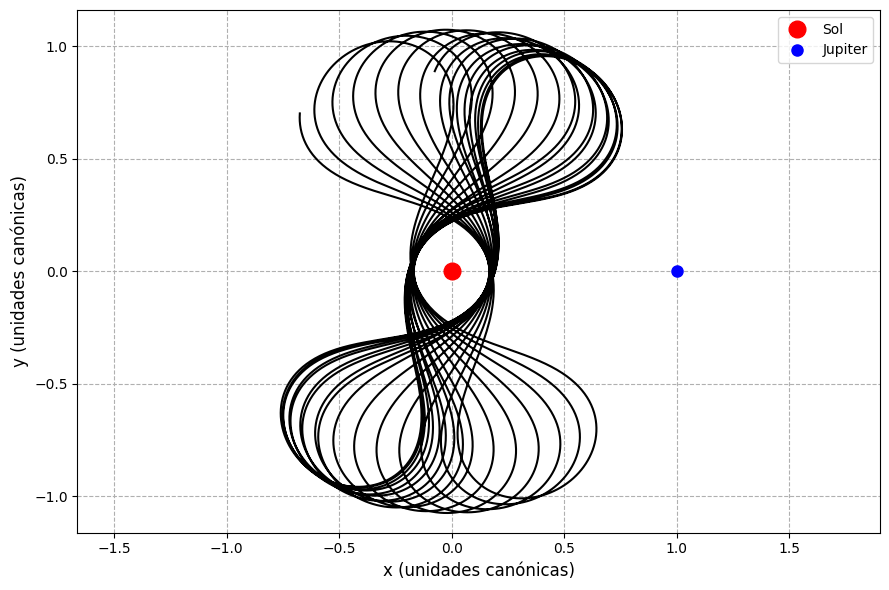

In [20]:
plt.figure(figsize=(6*1.5, 4*1.5))

plt.plot(rs[:,0], rs[:,1], color='black', linewidth=1.5)

plt.plot(-alpha, 0, 'o', color='red', markersize=12, label='Sol')
plt.plot(1 - alpha, 0, 'o', color='blue', markersize=8, label='Jupiter')

plt.xlabel('x (unidades canónicas)', fontsize=12)
plt.ylabel('y (unidades canónicas)', fontsize=12)
#plt.title('Trayectoria de Hiperión en el sistema Saturno-Titán (crtbp_solucion())', fontsize=14)

plt.grid(ls="--")
plt.axis('equal')

plt.legend()
plt.tight_layout();


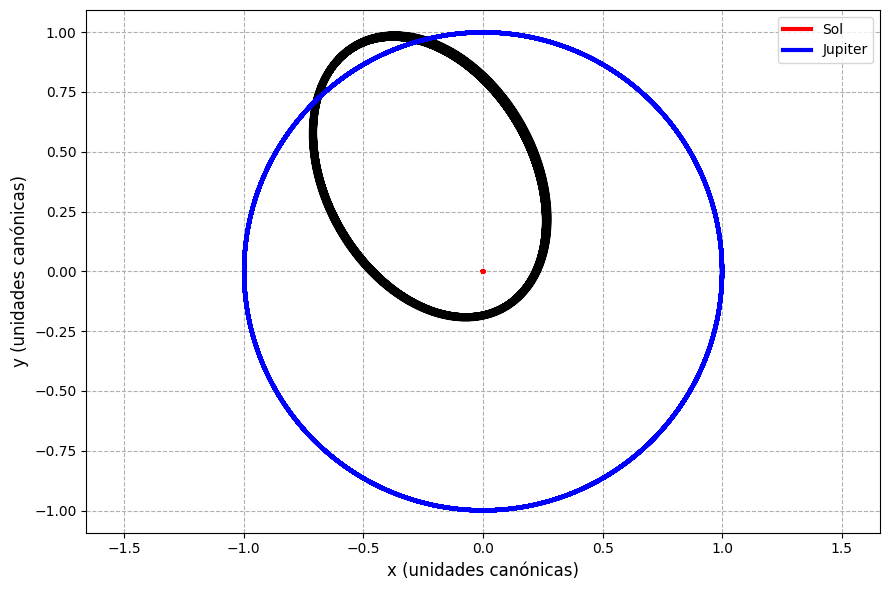

In [21]:
plt.figure(figsize=(6*1.5, 4*1.5))

plt.plot(ris[:,0], ris[:,1], color='black', linewidth=3)
plt.plot(r1s[:,0], r1s[:,1], color='red', linewidth=3, label='Sol')
plt.plot(r2s[:,0], r2s[:,1], color='blue', linewidth=3, label='Jupiter')


plt.xlabel('x (unidades canónicas)', fontsize=12)
plt.ylabel('y (unidades canónicas)', fontsize=12)

plt.grid(ls="--")
plt.axis('equal')

plt.legend()
plt.tight_layout();

In [22]:
Ng = 100
vmax = 1.5
xs = np.linspace(-vmax, vmax, Ng)
ys = np.linspace(-vmax, vmax, Ng)
Xs, Ys = np.meshgrid(xs, ys)
Zs = 0 * np.ones_like(Xs)
Xs.shape

(100, 100)

In [23]:
Vmods = np.zeros((Ng, Ng))
for iy in range(Ng):
  for ix in range(Ng):
    x = Xs[iy, ix]
    y = Ys[iy, ix]
    z = Zs[iy, ix]

    soft = 0.03
    x1 = -alpha
    x2 = 1 - alpha
    r1 = np.sqrt((x-x1)**2 + y**2 + z**2 + soft)
    r2 = np.sqrt((x-x2)**2 + y**2 + z**2 + soft)
    Vmods[iy, ix] = -(1-alpha)/r1 - alpha/r2 -1/2*(x**2+y**2)

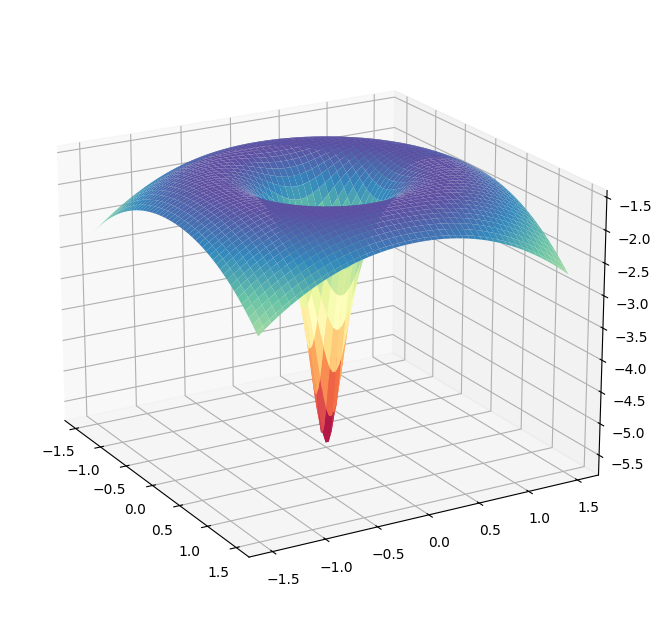

In [24]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
#ax.plot_surface(Xs, Ys, Vmods, cmap='viridis')
ax.plot_surface(Xs, Ys, Vmods, cmap='Spectral')
#ax.plot_surface(Xs, Ys, Vmods, cmap='inferno')
#ax.plot_surface(Xs, Ys, Vmods, cmap='prism')
ax.view_init(elev=20,azim=330)
plt.show()

In [25]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Surface(z=Vmods, x=Xs, y=Ys)])

fig.update_layout(title='Potencial Modificado en 3D (Plotly)', autosize=False,
                  scene_camera_eye=dict(x=1.86, y=0.18, z=0.61),
                  width=800, height=700,
                  margin=dict(l=65, r=50, b=65, t=90))

fig.show()

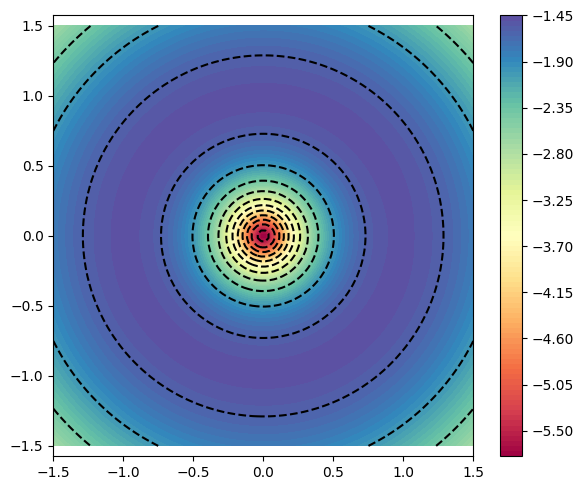

In [26]:
plt.figure(figsize=(6,5))

c1 = plt.contourf(Xs, Ys, Vmods, levels=100, cmap='Spectral')
plt.colorbar(c1)
c2 = plt.contour(Xs, Ys, Vmods, levels=10, colors='k')

plt.axis('equal')
plt.tight_layout()